En el caso de los ejemplos vistos anteriormente, cuando realizamos transmision inalambrica de estos datos, estamos hablando de modulacion digital. Esta transmision se puede realizar en diferentes estandares:
    - ASK (Amplitude Shift Key): donde modulamos una señal de carry continua por medio de señales ON-OFF que representan la informacion a transmitir. En este caso veriamos (por ejemplo) una cosenoidal cuando se transmite un 1 y nada cuando se transmite un 0.

    - FSK (Frequency Shift Key): Donde la señal de carry se cuenta con 2 frecuencias predefinidas (W_0 y W_1) que son intercaladas dependiendo de si se envia un 1 o un 0.

    - PSK (Phase Shift Key): En este caso se intercala el angulo de fase de la señal modulada, si realizamos estos cambios en cuatro cuadrantes podriamos transmitir 2 bits a la vez (caso de QPSK).

En cuanto a inconveniencias que conllevan el uso de estas metodologias tenemos:
    - ASK: Es suceptible a interferencias por ruido, debido a que este afecta en la amplitud, por lo que podriamos ver falsos "1" o "0". Este Efecto se presentaria en la demodulacion de la señal, por lo que seria mas propenso a aparecer errores por interferencia de ruido mientras mayor sea la distancia a recorrer por la señal.

    - FSK: Debido a que es necesario un mayor ancho de banda, es propenso a desvanecimiento selectivo en frecuencia, generandose variados niveles de atenuacion y cambios de fase. Entre otros tambien tenemos: baja eficiencia energetica (en comparacion con otros metodos) y mayor dificultad de sincronizacion de frecuencias entre dispositivos.

    - PSK: en el caso de transmision binaria (BPSK), tenemos una tasa de transmision de datos baja, dado que necesitamos un cambio de simbolo completo para poder representar el cambio de estado de 1 a 0 por ejemplo (baja velocidad de baudios). En el caso de QPSK tenemos un incremento en la complejidad del diseño del receptor, necesitando este distinguir entre 4 estados para representar los datos recibidos, ademas de introducir mayor suceptibilidad a cambios de fase e introduccion de AWGN en transmisiones inalambricas.


a) En la imagen podemos ver representado el funcionamiento de la modulacion PSK, donde la transmision de una señal de banda base = 1 indica la transmision de una señal de carry en fase. Mientras que al transmitir un 0 se transmite esta señal fuera de fase (ej: cos(w_0t + pi)). 

b) A continuacion se muestra un codigo de python con el que se puede lograr graficar una señal de carry modulada por una banda base como la mostrada en la figura de la consigna:


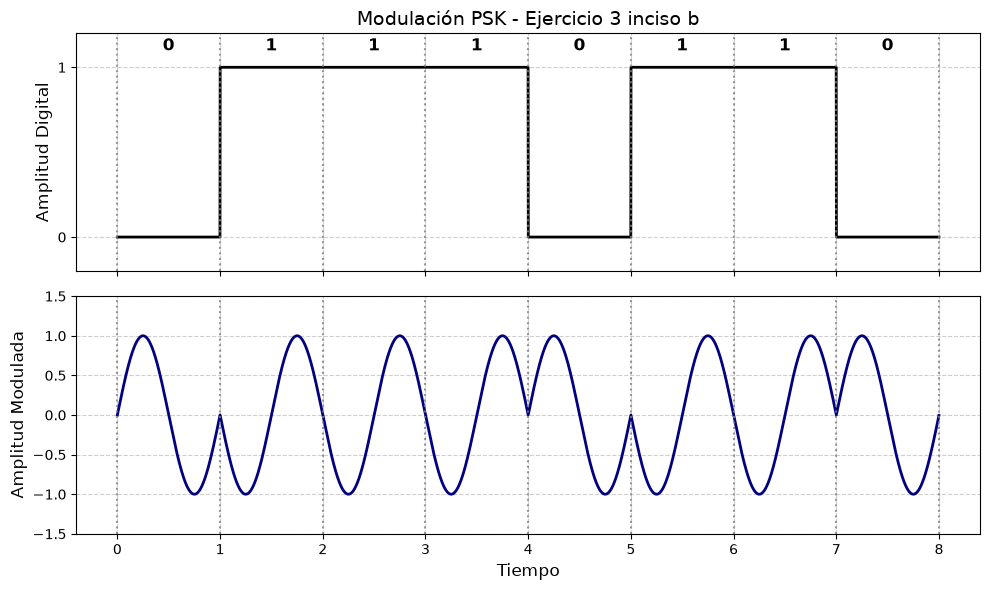

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#Secuencia de bits a transmitir
bits = [0, 1, 1, 1, 0, 1, 1, 0]


f = 1                   # Frecuencia constante (1 ciclo por cada intervalo)         
muestras_por_bit = 1000 # Resolución del gráfico                                    
tiempo_bit = 1          # Duración en segundos de cada bit                          
                                                                                    
t_total = np.array([])                                                              
senal_modulada = np.array([])                                                       
senal_digital = np.array([])                                                        
                                                                                    
# Generación de la señal                                                            
for i, bit in enumerate(bits):                                                      
    # Vector de tiempo para el bit actual                                           
    t = np.linspace(i * tiempo_bit, (i + 1) * tiempo_bit, muestras_por_bit,         
endpoint=False)                                                                       
    t_total = np.concatenate((t_total, t))                                          
                                                                                    
    # Señal digital                                                                 
    senal_digital = np.concatenate((senal_digital, np.ones(muestras_por_bit) * bit))
                                                                                    
    # Señal PSK: Misma frecuencia, diferente fase                                   
    if bit == 0:                                                                    
        # Fase 0 grados (arranca hacia arriba)                                      
        y = np.sin(2 * np.pi * f * t)                                               
    else:                                                                           
        # Fase 180 grados (arranca hacia abajo)                                     
        y = np.sin(2 * np.pi * f * t + np.pi)                                       
        # (Esto es matemáticamente equivalente a -np.sin(2 * np.pi * f * t))        
                                                                                    
    senal_modulada = np.concatenate((senal_modulada, y))                            
                                                                                    
# --- Creación de los Gráficos ---                                                  
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)                  
                                                                                    
# Gráfico de la señal digital                                                       
ax1.plot(t_total, senal_digital, color='black', linewidth=2)                        
ax1.set_ylim(-0.2, 1.2)                                                             
ax1.set_ylabel("Amplitud Digital", fontsize=12)                                     
ax1.set_yticks([0, 1])                                                              
ax1.grid(True, linestyle='--', alpha=0.6)                                           
ax1.set_title("Modulación PSK - Ejercicio 3 inciso b", fontsize=14)                 
                                                                                    
# Agregar los bits como texto arriba del gráfico                                    
for i, bit in enumerate(bits):                                                      
    ax1.text(i + 0.5, 1.1, str(bit), horizontalalignment='center', fontsize=12,     
fontweight='bold')                                                                    
                                                                                    
# Gráfico de la señal modulada (PSK)
ax2.plot(t_total, senal_modulada, color='navy', linewidth=2)
ax2.set_ylim(-1.5, 1.5)
ax2.set_ylabel("Amplitud Modulada", fontsize=12)
ax2.set_xlabel("Tiempo", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

# Marcar las separaciones de cada bit
for i in range(len(bits) + 1):
    ax1.axvline(x=i, color='gray', linestyle=':', alpha=0.8)
    ax2.axvline(x=i, color='gray', linestyle=':', alpha=0.8)

plt.tight_layout()
plt.show()